In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import scipy
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 8)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=6)
mpl.rc('ytick', labelsize=6)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=8)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=8)
mpl.rc('axes', linewidth=0.5)

In [12]:
import sys
import pandas as pd
sys.path.append("../")
import importlib
import util
import numpy as np
importlib.reload(util)  # 重新载入
# from util import 
Omegas_FOM = []
Amplitudes_FOM = []
# responses_FOM = np.zeros(num)
# As = [0.0938,0.125,0.1562,0.1875,0.2188,0.25,0.2812,0.3125,0.375,0.5,0.625,0.75]
As = [0.125,0.25,0.375,0.5,0.625,0.75]

# FOM obtaining
for i in range(len(As)):
    file = "../../Validation/MicroBeam/F_%.4f.csv"%As[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOM.append(data_FOM[0])
    Amplitudes_FOM.append(data_FOM[1])

Omegas_FOM_P = []
Phases_FOM = []
for i in range(1,6):
    file = "../../Validation/MicroBeam/F_%.4f_P.csv"%As[i]
    data_FOM_P = pd.read_csv(file, header = None)
    Phases_FOM.append(data_FOM_P[0])
    Omegas_FOM_P.append(data_FOM_P[1])

Project = './Beams/'
idx = 4
A = As[idx+1]
num = 10

result_i = pd.read_csv('%s/FRF/beta_%.4f_model_%d.csv'%(Project,A,num))
C_A = np.array([result_i['Freq'],result_i['Amplitude']]).T
C_P = np.array([result_i['Freq'],result_i['Phase']]).T
A_range = [0.1,8]
P_range = [0.1,3]
C_A_ref = np.array([Omegas_FOM[idx+1], Amplitudes_FOM[idx+1]]).T
C_P_ref = np.array([Omegas_FOM_P[idx], Phases_FOM[idx]]).T


In [13]:
As_ranges = [[0.1,2.5],[0.1,4],[0.1,5],[0.1,6.5],[0.1,7.5]]
mean_chamfer_beam = np.ones([56,5,2])
for i in range(56):
    for j in range(5):
        C_A_ref = np.array([Omegas_FOM[j+1], Amplitudes_FOM[j+1]]).T
        C_P_ref = np.array([Omegas_FOM_P[j], Phases_FOM[j]]).T
        A = As[j+1]
        result_i = pd.read_csv('%s/FRF/beta_%.4f_model_%d.csv'%(Project,A,i))
        C_A = np.array([result_i['Freq'],result_i['Amplitude']]).T
        C_P = np.array([result_i['Freq'],result_i['Phase']]).T
        mean_chamfer_beam[i,j,0] = np.mean(util.chamfer_oneway(C_A, C_A_ref, As_ranges[j]))
        mean_chamfer_beam[i,j,1] = np.mean(util.chamfer_oneway(C_P, C_P_ref, P_range))
        

(array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 55],
      dtype=int64),)


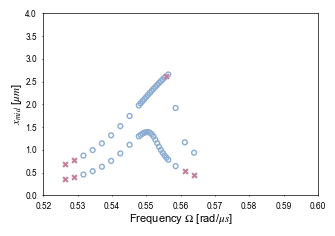

In [28]:
trainpoints = pd.read_csv('Beam_trainpoints.csv')
sucuess = np.where(np.mean(np.sum(mean_chamfer_beam, axis = 2), axis = 1)<0.1)
failure = np.where(np.mean(np.sum(mean_chamfer_beam, axis = 2), axis = 1)>=0.1)
print(sucuess)
fig,ax = plt.subplots(figsize = (9/2.54,6/2.54))
for i in range(2):
    ax.plot(Omegas_FOM[i], Amplitudes_FOM[i],lw = 1, color = 'gray')
size = 12
ax.scatter(trainpoints['freq'][sucuess[0]],trainpoints['frf'][sucuess[0]],marker='o',facecolors='none',   # 关键：空心
    edgecolors='#8BACD1', label = 'Succuess Inference', s = size)
ax.scatter(trainpoints['freq'][failure[0]],trainpoints['frf'][failure[0]], s = size, marker='x', color = '#C17F9E', label = 'Failed Inference')
ax.set_ylim(0,4)
ax.set_xlim(0.52,0.6)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlabel("Frequency $\Omega$ [rad/$\mu s$]")
ax.set_ylabel("$x_{mid}$ [$\mu m$]")
# ax.legend()
plt.savefig('./Beams/TrainPoint.svg',dpi = 300,transparent = True,bbox_inches="tight")

In [19]:
As = [1,1.5,2,2.5,3]
Omegas_FOM = []
Amplitudes_FOM = []

# FOM obtaining
for i in range(len(As)):
    file = "../../Validation/Micromirror2/beta%.1f-1.csv"%As[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOM.append(data_FOM[0])
    Amplitudes_FOM.append(data_FOM[1])

Omegas_FOM_P = []
Phases_FOM = []
for i in range(len(As)):
    file = "../../Validation/Micromirror2/beta%.1f-1-P.csv"%As[i]
    data_FOM_P = pd.read_csv(file, header = None)
    Phases_FOM.append(data_FOM_P[0])
    Omegas_FOM_P.append(data_FOM_P[1])

Project = './Mirrors/'
idx = 4
A = As[idx]
num = 10

result_i = pd.read_csv('%s/FRF/beta_%.4f_model_%d.csv'%(Project,A,num))
C_A = np.array([result_i['Freq'],result_i['Amplitude']]).T
C_P = np.array([result_i['Freq'],result_i['Phase']]).T
A_range = [0.01,12]
P_range = [0.01,3]
C_A_ref = np.array([Omegas_FOM[idx], Amplitudes_FOM[idx]]).T
C_P_ref = np.array([Omegas_FOM_P[idx], Phases_FOM[idx]]).T

In [21]:
mean_chamfer_mirror = np.ones([22,5,2])

for i in range(22):
    for j in range(5):
        C_A_ref = np.array([Omegas_FOM[j], Amplitudes_FOM[j]]).T
        C_P_ref = np.array([Omegas_FOM_P[j], Phases_FOM[j]]).T
        A = As[j]
        result_i = pd.read_csv('%s/FRF/beta_%.4f_model_%d.csv'%(Project,A,i))
        C_A = np.array([result_i['Freq'],result_i['Amplitude']]).T
        C_P = np.array([result_i['Freq'],result_i['Phase']+np.pi]).T
        mean_chamfer_mirror[i,j,0] = np.mean(util.chamfer_oneway(C_A, C_A_ref, As_ranges[j]))
        mean_chamfer_mirror[i,j,1] = np.mean(util.chamfer_oneway(C_P, C_P_ref, P_range))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21], dtype=int64),)


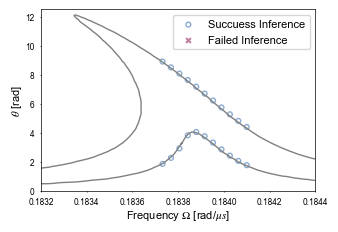

In [22]:
trainpoints = pd.read_csv('../../Validation/Micromirror2/trainset.csv')
sucuess = np.where(np.mean(np.sum(mean_chamfer_mirror, axis = 2), axis = 1)<0.1)
failure = np.where(np.mean(np.sum(mean_chamfer_mirror, axis = 2), axis = 1)>=0.1)
print(sucuess)
fig,ax = plt.subplots(figsize = (9/2.54,6/2.54))
for i in [0,4]:
    ax.plot(Omegas_FOM[i], Amplitudes_FOM[i],lw = 1, color = 'gray')
size = 12
ax.scatter(trainpoints['omegas'][sucuess[0]],trainpoints['As'][sucuess[0]],marker='o',facecolors='none',   # 关键：空心
    edgecolors='#8BACD1', label = 'Succuess Inference', s = size)
ax.scatter(trainpoints['omegas'][failure[0]],trainpoints['As'][failure[0]], s = size, marker='x', color = '#C17F9E', label = 'Failed Inference')
ax.set_ylim(0,12.5)
ax.set_xlim(0.1832,0.1844)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlabel("Frequency $\Omega$ [rad/$\mu s$]")
ax.set_ylabel(r"$\theta$ [rad]")
ax.legend()
plt.savefig('./Mirrors/TrainPoint.svg',dpi = 300,transparent = True,bbox_inches="tight")

In [101]:
np.mean(np.sum(mean_chamfer, axis = 2), axis = 1)

array([0.01098585, 0.01055767, 0.01239453, 0.05301942, 0.0106891 ,
       0.01047109, 0.01046917, 0.01060351, 0.0104843 , 0.04711823,
       0.01113294, 0.0099167 , 0.00973546, 0.00966921, 0.00932894,
       0.00903428, 0.00883246, 0.00886118, 0.008659  , 0.00859049,
       0.00851155, 0.00854418])

In [24]:
A1 = list(np.mean(mean_chamfer_beam[sucuess], axis = 1)[:,0])
B1 = list(np.mean(mean_chamfer_beam[sucuess], axis = 1)[:,1])
A2 = list(np.mean(mean_chamfer_mirror, axis = 1)[:,0])
B2 = list(np.mean(mean_chamfer_mirror, axis = 1)[:,1])


In [29]:
A1 = list(np.mean(mean_chamfer_beam[sucuess], axis = 1)[:,0])
B1 = list(np.mean(mean_chamfer_beam[sucuess], axis = 1)[:,1])
A2 = list(np.mean(mean_chamfer_mirror, axis = 1)[:,0])
B2 = list(np.mean(mean_chamfer_mirror, axis = 1)[:,1])


C:\Users\TengMa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\TengMa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\TengMa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\TengMa\anaconda3\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the

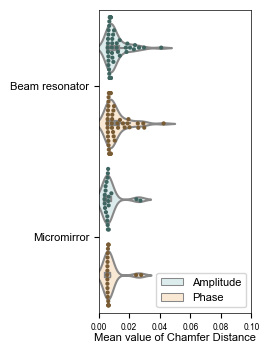

In [41]:
import seaborn as sns
df = pd.DataFrame({
    'value': A1+B1+A2+B2,
    'idx': (['A1']*len(A1) +
              ['B1']*len(B1) +
              ['A2']*len(A2) +
              ['B2']*len(B2)),
    'group': (['Amplitude']*len(A1) +
              ['Phase']*len(B1) +
              ['Amplitude']*len(A2) +
              ['Phase']*len(B2))
})
palette_point = {
    'Amplitude': '#3F6561',   # 蓝
    'Phase': '#795B34'    # 橙
}
palette_vio = {
    'Amplitude': '#D9EEEE',   # 蓝
    'Phase': '#FFE8CE'    # 橙
}
fig, ax = plt.subplots(figsize = (5/2.54,10/2.54))
sns.violinplot(
    data=df,
    x='value',
    y='idx',
    hue='group',      # 决定颜色
    orient='h',
    dodge=False,      # 非常重要：不左右分开
    # cut=0,
    palette=palette_vio,
)
ax = sns.swarmplot(
    data=df,
    x='value',
    y='idx',
    hue='group' ,       # legend 显示 1, 2
    orient='h',
    dodge=False,
    palette=palette_point,
    size=3,
    marker = 'o',
    legend=False
)
scale = 0.8   # <1 变窄，>1 变宽
for pc in ax.collections:
    if pc.__class__.__name__ == "PolyCollection":
        verts = pc.get_paths()[0].vertices
        y_center = verts[:, 1].mean()
        verts[:, 1] = y_center + (verts[:, 1] - y_center) * scale

ax.set_yticks([0.5, 2.5])
ax.set_yticklabels(["Beam resonator", "Micromirror"],fontsize = 8)
ax.set_ylabel('')
ax.set_xlabel("Mean value of Chamfer Distance")
ax.set_xlim((0,0.1))
plt.legend()
plt.savefig('Errorall.svg',dpi = 300,transparent = True,bbox_inches="tight")

In [238]:
np.mean(np.sum(mean_chamfer_beam, axis = 2), axis = 1)

array([0.35885172, 0.34724009, 0.08352369, 0.05564239, 0.03519739,
       0.0222804 , 0.02768628, 0.01358832, 0.01342895, 0.01273413,
       0.01412096, 0.01481299, 0.02004182, 0.01881453, 0.0144864 ,
       0.01369881, 0.01449255, 0.01355872, 0.01184073, 0.01940888,
       0.01520152, 0.02411127, 0.03724334, 0.04865852, 0.04971295,
       0.05957316, 0.33475776, 0.34597811, 0.33338496, 0.33184108,
       0.03769823, 0.0297104 , 0.01600557, 0.01319461, 0.01571623,
       0.01371214, 0.0120101 , 0.01359359, 0.01472895, 0.01784341,
       0.01750271, 0.01469314, 0.01267258, 0.01267617, 0.01207825,
       0.01595947, 0.01765785, 0.01711096, 0.01499809, 0.01209993,
       0.01637117, 0.71542828, 0.0252388 , 0.01252978, 0.01548993,
       0.04071023])

In [165]:
a = ['A1']*len(A1) +['B1']*len(B1) +['A2']*len(A2) +['B2']*len(B2)

In [166]:
len(a)

142